# 🔷 ALUR LENGKAP IMPLEMENTASI BI DASHBOARD (UNIVERSITAS SILIWANGI)
Dashboard Analitik Rasio Dosen dan Mahasiswa

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_theme(style="whitegrid")

## STEP 1 & 2 — Load Data (Dari Hasil ETL Star Schema)

In [2]:
# Load Fact Table dan Dimension Table yang sebelumnya sudah kita buat dari ETL
df_fact = pd.read_csv('Star_Schema/Fact_Kapasitas_Pendidikan.csv')
df_dim_prodi = pd.read_csv('Star_Schema/Dim_Prodi.csv')
df_dim_waktu = pd.read_csv('Star_Schema/Dim_Waktu.csv')

# Merge Data (Denormalize untuk visualisasi)
# Menggabungkan Fakta dengan Nama Prodi dan Tahun Pelaporan
df = pd.merge(df_fact, df_dim_prodi, on='id_prodi', how='left')
df = pd.merge(df, df_dim_waktu, on='id_waktu', how='left')

# Fokus pada prodi yang Aktif saja (jika ada filter yang diperlukan)
df = df[df['status_prodi'] == 'Aktif']

print("Beberapa baris pertama data gabungan:")
display(df[['tahun_pelaporan', 'nama_program_studi', 'jenjang', 'jumlah_mahasiswa', 'total_dosen', 'nilai_rasio']].head())

Beberapa baris pertama data gabungan:


,tahun_pelaporan,nama_program_studi,jenjang,jumlah_mahasiswa,total_dosen,nilai_rasio
0,Ganjil 2024,Animasi,D4,90,10,5.29
1,Ganjil 2024,Antropologi Budaya,S1,152,12,7.24
2,Ganjil 2024,Desain Komunikasi Visual,S1,738,16,18.45
3,Ganjil 2024,Desain Mode,D4,291,10,10.39
4,Ganjil 2024,Desain Produk,S1,95,9,7.92


## STEP 3 — Data Cleaning (Transform Phase) & Pengecekan Missing Value

In [3]:
# Cek missing values
print("\nJumlah Missing Values per kolom:")
display(df.isnull().sum())

# Hapus baris yang rasionya kosong (karena prodi tidak punya mahasiswa/dosen)
df = df.dropna(subset=['nilai_rasio', 'jumlah_mahasiswa', 'total_dosen'])

print(f"\nData bersih: {len(df)} baris.")


Jumlah Missing Values per kolom:


id_universitas                      0
id_prodi                            0
id_waktu                            0
jumlah_dosen_penghitung_rasio       0
dosen_tetap                         0
dosen_tidak_tetap                   0
total_dosen                         0
jumlah_mahasiswa                    0
rasio_dosen_mahasiswa               0
nilai_rasio                      2412
nama_program_studi                  0
jenjang                             0
status_prodi                        0
akreditasi_prodi                    0
tahun_pelaporan                     0
semester                            0
tahun                               0
dtype: int64


Data bersih: 12003 baris.


## STEP 4 & 5 — Agregasi Level Institusi (Universitas Siliwangi)

In [4]:
# Filter hanya untuk semester Ganjil saja (atau Genap) agar agregasinya tidak double dalam satu tahun
# Kita ambil Ganjil karena biasanya pelaporan PDDIKTI paling lengkap di Genap/Ganjil
# Atau kita bisa plot per urutan waktu (Ganjil 2023 -> Genap 2023 -> Ganjil 2024 dll)

# Ubah nama kolom agar mudah diingat
df['tahun'] = df['tahun'].astype(int)
df['jumlah_dosen'] = df['total_dosen'].astype(int)
df['jumlah_mahasiswa'] = df['jumlah_mahasiswa'].astype(int)

# Agregasi agregat total Universitas
df_institusi = df.groupby('tahun_pelaporan').agg({
    'jumlah_mahasiswa': 'sum',
    'jumlah_dosen': 'sum',
    'tahun': 'first',
    'semester': 'first'
}).reset_index()

# Urutkan berdasarkan waktu nyata
# Membuat kolom helper untuk pengurutan (misal 2023.1 untuk Ganjil, 2023.2 untuk Genap)
df_institusi['urutan_waktu'] = df_institusi['tahun'] + df_institusi['semester'].apply(lambda x: 0.1 if 'Ganjil' in x else 0.2)
df_institusi = df_institusi.sort_values('urutan_waktu').reset_index(drop=True)

# Hitung rasio total tingkat Universitas
df_institusi['rasio'] = (df_institusi['jumlah_mahasiswa'] / df_institusi['jumlah_dosen']).round(2)

print("Tabel Agregasi Level Institusi:")
display(df_institusi[['tahun_pelaporan', 'jumlah_mahasiswa', 'jumlah_dosen', 'rasio']])

Tabel Agregasi Level Institusi:


,tahun_pelaporan,jumlah_mahasiswa,jumlah_dosen,rasio
0,Ganjil 2023,843336,27970,30.15
1,Genap 2023,792924,28134,28.18
2,Ganjil 2024,896113,31823,28.16
3,Genap 2024,896852,34070,26.32
4,Ganjil 2025,884656,36106,24.50


## STEP 6 — VISUALISASI DASHBOARD (Deployment)

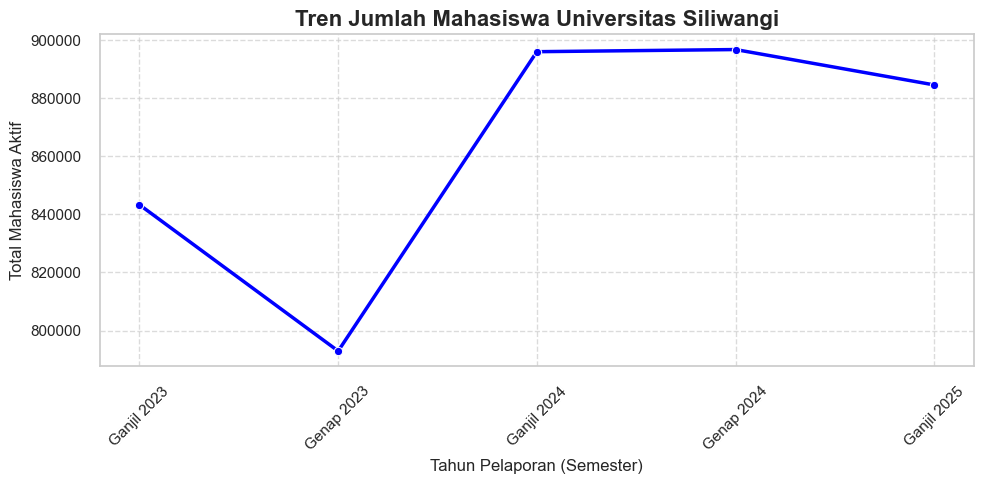

In [5]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_institusi, x='tahun_pelaporan', y='jumlah_mahasiswa', marker='o', color='blue', linewidth=2.5)
plt.title('Tren Jumlah Mahasiswa Universitas Siliwangi', fontsize=16, fontweight='bold')
plt.xlabel('Tahun Pelaporan (Semester)', fontsize=12)
plt.ylabel('Total Mahasiswa Aktif', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('grafik_mhs_unsil.png', dpi=300)
plt.show()

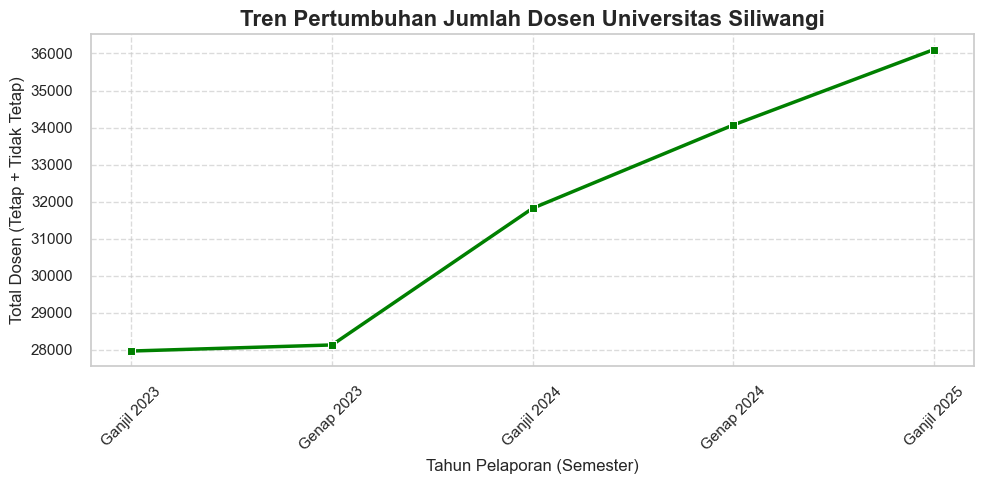

In [6]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_institusi, x='tahun_pelaporan', y='jumlah_dosen', marker='s', color='green', linewidth=2.5)
plt.title('Tren Pertumbuhan Jumlah Dosen Universitas Siliwangi', fontsize=16, fontweight='bold')
plt.xlabel('Tahun Pelaporan (Semester)', fontsize=12)
plt.ylabel('Total Dosen (Tetap + Tidak Tetap)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('grafik_dosen_unsil.png', dpi=300)
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_27276\3178674882.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_institusi, x='tahun_pelaporan', y='rasio', palette='viridis')


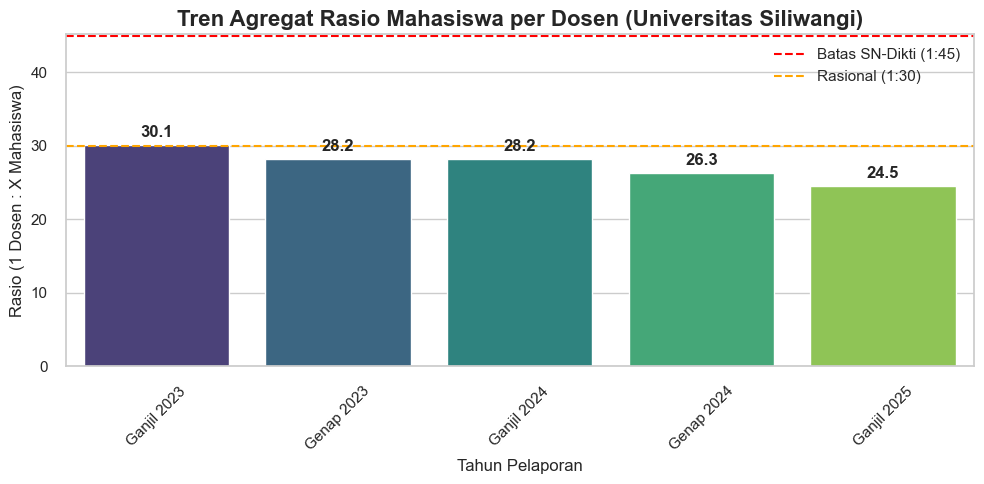

In [7]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=df_institusi, x='tahun_pelaporan', y='rasio', palette='viridis')

# Menambahkan angka rasio di atas bar chart
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontweight='bold')

# Menambahkan Garis Batas Ideal (Misal threshold 1:45 untuk IPS/Humaniora dan 1:30 untuk Eksakta)
plt.axhline(y=45, color='red', linestyle='--', label='Batas SN-Dikti (1:45)')
plt.axhline(y=30, color='orange', linestyle='--', label='Rasional (1:30)')

plt.title('Tren Agregat Rasio Mahasiswa per Dosen (Universitas Siliwangi)', fontsize=16, fontweight='bold')
plt.xlabel('Tahun Pelaporan', fontsize=12)
plt.ylabel('Rasio (1 Dosen : X Mahasiswa)', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.ylim(0, max(df_institusi['rasio']) + 15) # Memberi ruang di bagian atas grafik
plt.tight_layout()
plt.savefig('grafik_rasio_unsil.png', dpi=300)
plt.show()

## STEP 7 — Grafik Top 5 Program Studi Paling "Overload" (Rasio Tertinggi)

C:\Users\HP\AppData\Local\Temp\ipykernel_27276\3830192244.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_latest_sorted, x='nilai_rasio', y='nama_program_studi', palette='autumn')


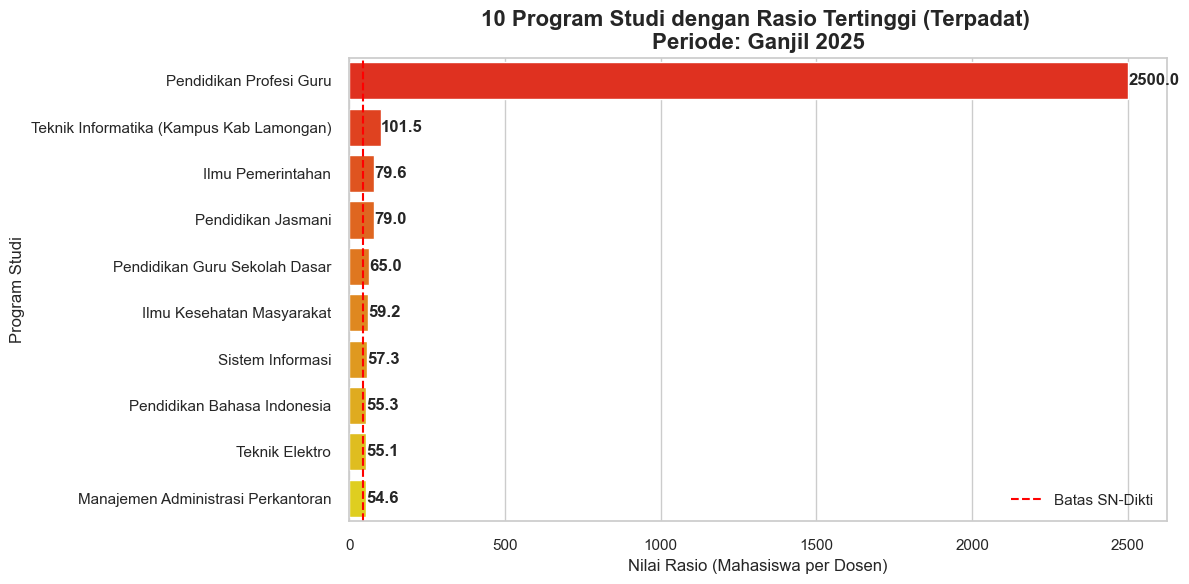

In [8]:
# Mari ambil data semester terakhir yang dilaporkan
semester_terakhir = df['urutan_waktu'] = df['tahun'] + df['semester'].apply(lambda x: 0.1 if 'Ganjil' in x else 0.2)
max_waktu = semester_terakhir.max()
df_latest = df[df['urutan_waktu'] == max_waktu].copy()

# Urutkan berdasarkan rasio paling tinggi
df_latest_sorted = df_latest.sort_values(by='nilai_rasio', ascending=False).head(10)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df_latest_sorted, x='nilai_rasio', y='nama_program_studi', palette='autumn')

plt.title(f'10 Program Studi dengan Rasio Tertinggi (Terpadat) \nPeriode: {df_latest["tahun_pelaporan"].iloc[0]}', fontsize=16, fontweight='bold')
plt.xlabel('Nilai Rasio (Mahasiswa per Dosen)', fontsize=12)
plt.ylabel('Program Studi', fontsize=12)

plt.axvline(x=45, color='red', linestyle='--', label='Batas SN-Dikti')

for p in ax.patches:
    width = p.get_width()    # dapatkan lebar batang
    ax.text(width + 1,       # letakkan sedikit ke kanan batang
            p.get_y() + p.get_height() / 2, # posisi y di tengah batang
            '{:1.1f}'.format(width),
            ha = 'left',   # perataan horizontal
            va = 'center', # perataan vertikal
            fontweight='bold')

plt.legend()
plt.tight_layout()
plt.savefig('grafik_top10_rasio_prodi.png', dpi=300)
plt.show()